# 02d - Statistics and formal validation

**Requires:** run `02a_pipeline.ipynb` and `02c_benchmarks.ipynb` first.

- §14 Continuous motion-preservation metrics
- §14b Population statistics over many videos
- §15 Statistical validation: Wilcoxon and bootstrap intervals
- §16 Effect on downstream classification
- §17 Consolidated benchmark table

In [1]:
# ── Load experiment configuration from YAML ──────────────────────────────────
import sys, os, random
from pathlib import Path

_cwd = Path(os.getcwd())
REPO_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src").exists() and (p / "configs").exists()),
    _cwd,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from omegaconf import OmegaConf
import numpy as np

cfg = OmegaConf.load(REPO_ROOT / "configs/skeleton.yaml")

# Dataset
LAB_ID            = cfg.dataset.lab_id
FRAME_LIMIT       = cfg.dataset.frame_limit
FRAME_LIMIT_BENCH = cfg.dataset.frame_limit_bench
RANDOM_SEED       = cfg.dataset.random_seed

# Outlier detection
SPEED_MAD_K          = cfg.outlier.speed_mad_k
LENGTH_THRESHOLD     = cfg.outlier.length_threshold
VIOLATION_REPORT_THR = cfg.outlier.violation_report_thr
DETECTION_N_SIGMA    = cfg.outlier.detection_n_sigma

# Optimizer weights
LAMBDA_L          = cfg.weights.L
LAMBDA_S          = cfg.weights.S
LAMBDA_T          = cfg.weights.T
LAMBDA_ACC        = cfg.weights.acc
LAMBDA_ANGLE      = cfg.weights.angle
LAMBDA_JERK       = cfg.weights.jerk
LAMBDA_ANGLE_CONT = cfg.weights.angle_cont

# Solver
OUTLIER_ADHESION           = cfg.solver.outlier_adhesion
N_PASSES                   = cfg.solver.n_passes
CONFIDENCE_SIGMA           = cfg.solver.confidence_sigma
ADAPTIVE_K                 = cfg.solver.adaptive_k
MAX_DISP_FACTOR            = cfg.solver.max_disp_factor
NON_OUTLIER_ADHESION_SCALE = cfg.solver.non_outlier_adhesion_scale

# Benchmark synthetic
BENCH_NOISE_STD       = cfg.benchmark.noise_std
BENCH_DROPOUT_RATE    = cfg.benchmark.dropout_rate
BENCH_SWAP_PROB       = cfg.benchmark.swap_prob
BENCH_SPEED_SPIKES    = cfg.benchmark.speed_spikes
BENCH_DRIFT_AMPLITUDE = cfg.benchmark.drift_amplitude
BENCH_LAMBDA_L        = cfg.benchmark.lambda_l
BENCH_ADHESION        = cfg.benchmark.adhesion

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"▶  config loaded from {REPO_ROOT / 'configs/skeleton.yaml'}")
print(f"   LAB_ID={LAB_ID}  FRAME_LIMIT={FRAME_LIMIT}  RANDOM_SEED={RANDOM_SEED}")
print(f"   LAMBDA_L={LAMBDA_L}  LAMBDA_T={LAMBDA_T}  OUTLIER_ADHESION={OUTLIER_ADHESION}")


▶  config loaded from c:\Users\User\dev\tfm\configs\skeleton.yaml
   LAB_ID=CalMS21_task1  FRAME_LIMIT=1500  RANDOM_SEED=42
   LAMBDA_L=12.0  LAMBDA_T=0.8  OUTLIER_ADHESION=0.6


In [2]:
# ── Load artifacts produced by 02a_pipeline.ipynb ────────────────────────────
import pickle, json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Probe both the canonical repo results dir and the notebook-local one
# (the latter is used when 02a was run before the REPO_ROOT fix).
_results_candidates = [REPO_ROOT / "results", Path(os.getcwd()) / "results"]
RESULTS_DIR = next(
    (p for p in _results_candidates if (p / "run_config.json").exists()),
    REPO_ROOT / "results",
)
OUTPUTS_DIR = REPO_ROOT / "outputs"

_run_cfg = json.load(open(RESULTS_DIR / "run_config.json"))
VIDEO_ID   = _run_cfg["video_id"]
MOUSE_ID   = _run_cfg["mouse_id"]
ARENA_DIAG = _run_cfg["arena_diag"]
VIDEO_FPS  = _run_cfg.get("video_fps", 30)

df_sample    = pickle.load(open(RESULTS_DIR / f"df_sample_{VIDEO_ID}.pkl",    "rb"))
df_corrected = pickle.load(open(RESULTS_DIR / f"df_corrected_{VIDEO_ID}.pkl", "rb"))
skeleton     = pickle.load(open(RESULTS_DIR / f"skeleton_{LAB_ID}.pkl",       "rb"))

# L_ref_px convenience alias used in §9b
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
_w_ref  = _to_wide(df_sample[df_sample["mouse_id"] == MOUSE_ID])
_l_ref  = _segment_length(_w_ref, "nose", "tail_base")
L_ref_px = float(_l_ref[_l_ref > 10].median())

print(f"Loaded from: {RESULTS_DIR}")
print(f"  VIDEO_ID={VIDEO_ID} | MOUSE_ID={MOUSE_ID}")
print(f"  df_sample: {len(df_sample)} rows  |  df_corrected: {len(df_corrected)} rows")
print(f"  skeleton: {len(skeleton.keypoints)} kp, {len(skeleton.edges)} edges, "
      f"L_body={skeleton.L_body_median_px:.1f} px")
print(f"  L_ref_px={L_ref_px:.1f} px")


Loaded from: c:\Users\User\dev\tfm\notebooks\02_skeleton_correction\results
  VIDEO_ID=13638642 | MOUSE_ID=1
  df_sample: 21000 rows  |  df_corrected: 21000 rows
  skeleton: 7 kp, 7 edges, L_body=175.5 px
  L_ref_px=207.5 px


## §14 Continuous motion-preservation metrics

The binary violation rate stops being useful once the baseline approaches zero.
Video 1036913557 is the clear case: 3.4% before and 2.7% after, a difference that
says almost nothing about whether the correction helped or harmed the trajectory.

These metrics do not depend on the detection threshold. They ask a different
question: after correcting, is this still the same movement?

| Metric | Reads as | Better |
|---|---|---|
| `accel_rms_norm` | normalised acceleration smoothness | lower |
| `jerk_energy_norm` | jerk energy, that is, tremor | lower |
| `spectral_energy_ratio` | power spectrum preserved | near 1.0 |
| `velocity_kl_divergence` | speed distribution preserved | near 0 |
| `turn_ks_stat` | KS test on turn angles | near 0 |

In [3]:
from src.skeleton.metrics import (
    motion_preservation_report,
    acceleration_smoothness,
    jerk_energy,
    spectral_energy_ratio,
    velocity_kl_divergence,
    turning_angle_distribution,
)

# Usar df_corrected (mejor variante multi-paso) vs df_sample (raw)
_report = motion_preservation_report(
    df_before=df_sample,
    df_after=df_corrected,
    mouse_id=MOUSE_ID,
    fps=VIDEO_FPS,
    l_body_px=L_ref_px,
    arena_diag=ARENA_DIAG,
)
print("Motion preservation report (before = raw tracking, after = best correction):")
print(_report.to_string(index=False))


Motion preservation report (before = raw tracking, after = best correction):
 keypoint                 metric  value_before  value_after     delta   interpretation
     nose         accel_rms_norm      0.132179     0.162633  0.030454  lower_is_better
tail_base         accel_rms_norm      0.116787     0.116787  0.000000  lower_is_better
     neck         accel_rms_norm      0.115409     0.143783  0.028374  lower_is_better
     nose       jerk_energy_norm     79.793400   123.603000 43.809600  lower_is_better
tail_base       jerk_energy_norm     60.726900    60.726900  0.000000  lower_is_better
     neck       jerk_energy_norm     59.694700    95.398700 35.704000  lower_is_better
     neck  spectral_energy_ratio      1.000000     0.976300 -0.023700 near_1.0_is_best
     nose  spectral_energy_ratio      1.000000     0.997800 -0.002200 near_1.0_is_best
tail_base  spectral_energy_ratio      1.000000     1.000000  0.000000 near_1.0_is_best
     nose velocity_kl_divergence      0.000000     0.

## §14c Spectral and curvature diagnostics

Three more metrics, covering aspects of the movement that acceleration and jerk
miss:

| Metric | What it measures | Ideal |
|---|---|---|
| `spectral_entropy` | spectral spread of the motion, in nats; low means smooth | lower after correction |
| `motion_bandwidth` | frequency containing 90% of the power, in Hz | should not increase |
| `curvature_preservation_ratio` | normalised curvature after over before | near 1: smoothed without erasing real turns |

In [4]:
from src.skeleton.metrics import (
    spectral_entropy,
    motion_bandwidth,
    trajectory_curvature_metrics,
)

# ── Spectral diagnostics ──────────────────────────────────────────────────────
_se_before = spectral_entropy(df_sample,    mouse_id=MOUSE_ID, fps=VIDEO_FPS)
_se_after  = spectral_entropy(df_corrected, mouse_id=MOUSE_ID, fps=VIDEO_FPS)
_bw_before = motion_bandwidth(df_sample,    mouse_id=MOUSE_ID, fps=VIDEO_FPS)
_bw_after  = motion_bandwidth(df_corrected, mouse_id=MOUSE_ID, fps=VIDEO_FPS)

print("── Spectral diagnostics ─────────────────────────────────────────")
print(f"  Spectral entropy  before: {_se_before:.4f} nats  →  after: {_se_after:.4f} nats"
      f"  (Δ = {_se_after - _se_before:+.4f})")
print(f"  Motion bandwidth  before: {_bw_before:.3f} Hz   →  after: {_bw_after:.3f} Hz"
      f"  (Δ = {_bw_after - _bw_before:+.3f})")
print()

# ── Curvature metrics ─────────────────────────────────────────────────────────
_curv = trajectory_curvature_metrics(
    df_before=df_sample,
    df_after=df_corrected,
    mouse_id=MOUSE_ID,
    fps=VIDEO_FPS,
    l_body_px=L_ref_px,
)
print("── Trajectory curvature (normalised by body length) ─────────────")
print(_curv.to_string(index=False))
print()
print("Interpretation: ratio < 1 → smoother; ratio ≈ 1 → curvature preserved; ratio > 1 → over-correction")


── Spectral diagnostics ─────────────────────────────────────────
  Spectral entropy  before: 1.4970 nats  →  after: 1.5226 nats  (Δ = +0.0255)
  Motion bandwidth  before: 0.410 Hz   →  after: 0.419 Hz  (Δ = +0.008)

── Trajectory curvature (normalised by body length) ─────────────
 keypoint  curvature_before  curvature_after  curvature_preservation_ratio
     nose          0.047293         0.036323                      0.768051
ear_right          0.031687         0.054725                      1.727067
hip_right          0.031379         0.074853                      2.385445
 hip_left          0.029546         0.067779                      2.294024
 ear_left          0.029297         0.052411                      1.788986
     neck          0.024240         0.039490                      1.629148
tail_base          0.023839         0.023839                      1.000000

Interpretation: ratio < 1 → smoother; ratio ≈ 1 → curvature preserved; ratio > 1 → over-correction


## §14b Population statistics

§14 measured motion preservation on the reference video. One video cannot say
whether those numbers are stable, so the same metrics are computed over every
available recording.

| Column | Meaning |
|---|---|
| `viol_rate_before` | violation rate of the raw tracking |
| `viol_rate_after` | violation rate after correction |
| `viol_reduction_pct` | relative reduction |
| `jerk_nose` | normalised jerk energy at the nose |
| `ms_per_frame` | processing time per frame |

In [5]:
# Population statistics: load the helper from src.skeleton
from src.skeleton._parallel_worker import process_one_video_population
from src.data.loader import load_tracking, load_metadata

# Population parameters
MAX_POP_VIDEOS = cfg.population.max_videos
POP_FRAME_LIMIT = cfg.population.frame_limit

print(f"process_one_video_population imported")
print(f"MAX_POP_VIDEOS={MAX_POP_VIDEOS}  POP_FRAME_LIMIT={POP_FRAME_LIMIT}")


process_one_video_population importado
MAX_POP_VIDEOS=5  POP_FRAME_LIMIT=400


In [6]:
# Multi-video population statistics
# ─────────────────────────────────────────────────────────────────────────────
# Takes up to MAX_POP_VIDEOS videos from the current lab, runs smooth_video over
# each one, and aggregates the population metrics.

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.skeleton.keypoint_smoother import smooth_video
from src.skeleton.mouse_skeleton import _to_wide, _segment_length
from src.skeleton.kinematic_constraints import compute_constraint_violations
from src.skeleton.metrics import jerk_energy

MAX_POP_VIDEOS  = 5
POP_FRAME_LIMIT = FRAME_LIMIT_BENCH  # 400 frames, same as the benchmark

# ── Select videos from the same lab ──────────────────────────────────────────
_tracking_dir = (
    REPO_ROOT / "dataset/MABe-mouse-behavior-detection/train_tracking" / LAB_ID
)
if _tracking_dir.exists():
    _avail_videos = sorted([p.stem for p in _tracking_dir.glob("*.parquet")])[:MAX_POP_VIDEOS]
else:
    _avail_videos = [str(VIDEO_ID)]

print(f"Videos available in {LAB_ID}: {_avail_videos}")

# Load the DataFrames, reusing df_sample when it already matches VIDEO_ID
_pop_candidates = []
for _vid in _avail_videos:
    try:
        _df_t = (df_sample if str(_vid) == str(VIDEO_ID)
                 else load_tracking(_vid, LAB_ID))
        if _df_t is not None and len(_df_t) > 50:
            _pop_candidates.append({"video_id": _vid, "lab_id": LAB_ID, "df": _df_t})
    except Exception as _e:
        print(f"  [{_vid}] not loaded: {_e}")

print(f"Candidate videos found: {len(_pop_candidates)}")

# ── Per-video processing function ────────────────────────────────────────────
def _process_one_video_pop(video_id, lab_id, df_tracking):
    """Run the pipeline over a single video and return its metrics."""
    _frames = sorted(df_tracking["video_frame"].unique())[:POP_FRAME_LIMIT]
    _df = df_tracking[df_tracking["video_frame"].isin(_frames)].copy()
    _mouse = _df["mouse_id"].iloc[0]

    _t0 = time.perf_counter()
    try:
        _df_c, _rep = smooth_video(
            _df,
            lab_id=lab_id,
            lambda_l=LAMBDA_L,
            lambda_t=LAMBDA_T,
            lambda_acc=LAMBDA_ACC,
            lambda_angle=LAMBDA_ANGLE,
            lambda_jerk=LAMBDA_JERK,
            lambda_angle_cont=LAMBDA_ANGLE_CONT,
            auto_edge_lambdas=True,
            outlier_adhesion=OUTLIER_ADHESION,
            n_passes=N_PASSES,
            pre_smooth_window=9,
        )
    except Exception as _e:
        return {"video_id": video_id, "error": str(_e)}
    _elapsed = time.perf_counter() - _t0

    _wide_b = _to_wide(_df[_df["mouse_id"] == _mouse])
    _wide_a = _to_wide(_df_c[_df_c["mouse_id"] == _mouse])

    # Per-video L_body for normalisation: the median excluding dropout frames
    _lb = _segment_length(_wide_b, "nose", "tail_base")
    _l_body_vid = float(_lb[_lb > 10].median()) if (_lb > 10).sum() > 5 else L_ref_px

    def _vr(wide):
        _l_ser = _segment_length(wide, "nose", "tail_base")
        _v = compute_constraint_violations(
            wide, skeleton, {},
            _l_ser,
            threshold=VIOLATION_REPORT_THR,  # a 0.25 fraction, not a z-score
        )
        return float(_v["violation_rate"].mean())

    _vr_b = _vr(_wide_b)
    _vr_a = _vr(_wide_a)
    _reduction = (_vr_b - _vr_a) / max(_vr_b, 1e-9) * 100

    _jerk_b = jerk_energy(_df,   _mouse, _l_body_vid, keypoints=["nose"])
    _jerk_a = jerk_energy(_df_c, _mouse, _l_body_vid, keypoints=["nose"])
    _jerk_nose_b = float(_jerk_b["jerk_energy_norm"].iloc[0]) if len(_jerk_b) > 0 else float("nan")
    _jerk_nose_a = float(_jerk_a["jerk_energy_norm"].iloc[0]) if len(_jerk_a) > 0 else float("nan")

    _ms_per_frame = _elapsed / max(len(_frames), 1) * 1000

    return {
        "video_id":           video_id,
        "n_frames":           len(_frames),
        "viol_rate_before":   round(_vr_b, 5),
        "viol_rate_after":    round(_vr_a, 5),
        "viol_reduction_pct": round(_reduction, 1),
        "jerk_nose_before":   round(_jerk_nose_b, 4),
        "jerk_nose_after":    round(_jerk_nose_a, 4),
        "ms_per_frame":       round(_ms_per_frame, 2),
        "error":              None,
    }

# ── Sequential processing ────────────────────────────────────────────────────
pop_results = []
for _cand in _pop_candidates:
    print(f"  Processing {_cand['video_id']}...", end=" ", flush=True)
    _r = _process_one_video_pop(_cand["video_id"], _cand["lab_id"], _cand["df"])
    if _r.get("error"):
        print(f"ERROR: {_r['error']}")
    else:
        print(f"viol {_r['viol_rate_before']:.3%}\u2192{_r['viol_rate_after']:.3%}  "
              f"\u0394={_r['viol_reduction_pct']:.1f}%  "
              f"jerk: {_r['jerk_nose_before']:.4f}\u2192{_r['jerk_nose_after']:.4f}  "
              f"{_r['ms_per_frame']:.1f} ms/frame")
    pop_results.append(_r)

# ── Summary table ────────────────────────────────────────────────────────────
pop_df = pd.DataFrame([r for r in pop_results if r.get("error") is None])
if len(pop_df):
    print("\nPopulation summary:")
    print(pop_df[[
        "video_id", "n_frames",
        "viol_rate_before", "viol_rate_after", "viol_reduction_pct",
        "jerk_nose_before", "jerk_nose_after", "ms_per_frame",
    ]].to_string(index=False))

    _cols_num = ["viol_rate_before", "viol_rate_after", "viol_reduction_pct",
                 "jerk_nose_before", "jerk_nose_after", "ms_per_frame"]
    _means = pop_df[_cols_num].mean()
    _stds  = pop_df[_cols_num].std()
    print("\nPopulation statistics (mean \u00b1 std):")
    for _col in _cols_num:
        print(f"  {_col:25s}: {_means[_col]:.4f} \u00b1 {_stds[_col]:.4f}")


Vídeos disponibles en CalMS21_task1: ['1011533560', '1036913557', '1062887364', '1087101060', '1089428234']
Vídeos candidatos encontrados: 5
  Procesando 1011533560... 

  mouse 1:   0%|          | 0/5 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/7 [00:00<?, ?win/s]

viol 21.214%→14.464%  Δ=31.8%  jerk: 2.3779→5.5420  17.8 ms/frame
  Procesando 1036913557... 

  mouse 1:   0%|          | 0/2 [00:00<?, ?win/s]

...

  mouse 2: 0win [00:00, ?win/s]

viol 0.000%→0.000%  Δ=0.0%  jerk: 0.0000→0.0000  0.6 ms/frame
  Procesando 1089428234... 

  mouse 1:   0%|          | 0/10 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/8 [00:00<?, ?win/s]

viol 24.607%→26.857%  Δ=-9.1%  jerk: 62.4971→37.9289  23.1 ms/frame

Resumen de población:
  video_id  n_frames  viol_rate_before  viol_rate_after  viol_reduction_pct  jerk_nose_before  jerk_nose_after  ms_per_frame
1011533560       400           0.21214          0.14464                31.8            2.3779           5.5420         17.79
1036913557       400           0.00679          0.02143              -215.8           50.6944          51.8529          4.05
1062887364       400           0.00000          0.00000                 0.0            0.0000           0.0000          0.61
1087101060       400           0.00000          0.00000                 0.0            0.0000           0.0000          0.60
1089428234       400           0.24607          0.26857                -9.1           62.4971          37.9289         23.09

Estadísticas de población (media ± std):
  viol_rate_before         : 0.0930 ± 0.1249
  viol_rate_after          : 0.0869 ± 0.1180
  viol_reduction_pct       

C:\Users\User\AppData\Local\Temp\ipykernel_35624\861911394.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_pop[1].set_xticklabels(_vids, rotation=20, ha='right', fontsize=8)


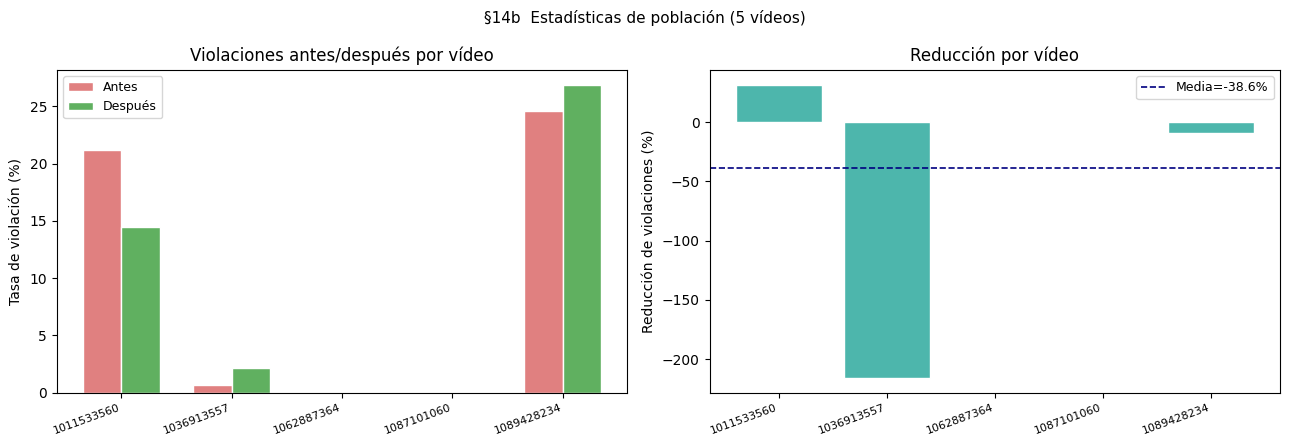

In [7]:
# ── Visualisation ────────────────────────────────────────────────────────
if len(pop_df) > 1:
    fig_pop, axes_pop = plt.subplots(1, 2, figsize=(13, 4.5))

    _vids = [str(v)[-10:] for v in pop_df['video_id']]  # truncate long IDs
    _x = np.arange(len(_vids))
    _w = 0.35

    axes_pop[0].bar(_x - _w/2, pop_df['viol_rate_before'] * 100, _w,
                    label='Before', color='#e08080', edgecolor='white')
    axes_pop[0].bar(_x + _w/2, pop_df['viol_rate_after'] * 100, _w,
                    label='After', color='#60b060', edgecolor='white')
    axes_pop[0].set_xticks(_x)
    axes_pop[0].set_xticklabels(_vids, rotation=20, ha='right', fontsize=8)
    axes_pop[0].set_ylabel('Violation rate (%)')
    axes_pop[0].set_title('Violations before/after, per video')
    axes_pop[0].legend(fontsize=9)

    axes_pop[1].bar(_vids, pop_df['viol_reduction_pct'],
                    color='#4db6ac', edgecolor='white')
    axes_pop[1].axhline(float(_means['viol_reduction_pct']),
                        color='navy', ls='--', lw=1.2,
                        label=f'Media={_means["viol_reduction_pct"]:.1f}%')
    axes_pop[1].set_xticklabels(_vids, rotation=20, ha='right', fontsize=8)
    axes_pop[1].set_ylabel('Violation reduction (%)')
    axes_pop[1].set_title('Reduction per video')
    axes_pop[1].legend(fontsize=9)

    plt.suptitle(f'Population statistics ({len(pop_df)} videos)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("\n(Only 1 video processed; the plot needs at least 2)")

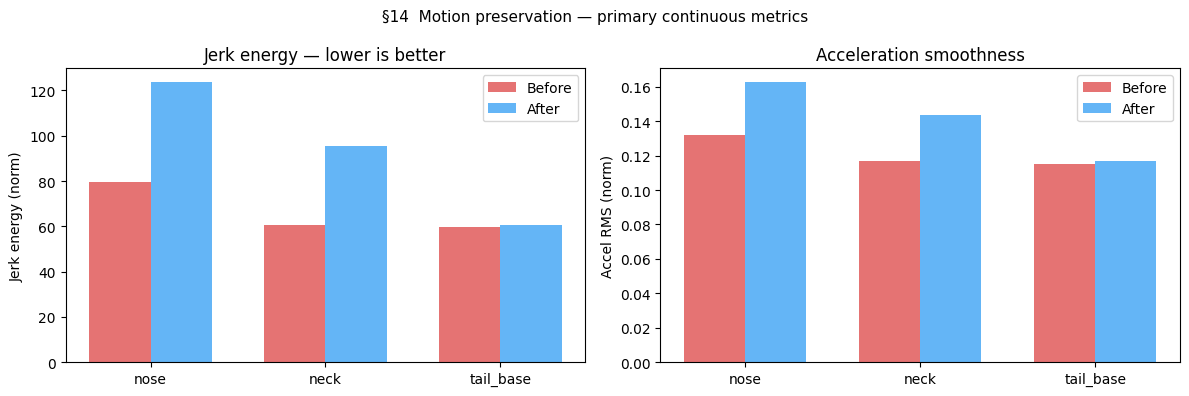


Spectral energy ratio (near 1.0 = motion spectrum preserved):
 keypoint  energy_before  energy_after  energy_ratio
     neck      7830.2202     7644.5466        0.9763
     nose      7793.5171     7776.5154        0.9978
tail_base      7460.5303     7460.5307        1.0000

Velocity KL divergence (lower = speed distribution preserved):
 keypoint  kl_div  ks_stat  ks_pval
     nose  0.0396   0.0660   0.0027
     neck  0.0300   0.0807   0.0001
tail_base  0.0000   0.0007   1.0000


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Bar chart: jerk_energy and accel_rms, before and after ───────────────
_kps_plot = [kp for kp in ["nose", "neck", "tail_base"]
             if kp in df_sample["bodypart"].unique()]

jerk_b = jerk_energy(df_sample,    MOUSE_ID, L_ref_px, _kps_plot)
jerk_a = jerk_energy(df_corrected, MOUSE_ID, L_ref_px, _kps_plot)
accel_b = acceleration_smoothness(df_sample,    MOUSE_ID, L_ref_px, _kps_plot)
accel_a = acceleration_smoothness(df_corrected, MOUSE_ID, L_ref_px, _kps_plot)

_x = np.arange(len(_kps_plot))
_w = 0.35

fig_mp, (ax_j, ax_a) = plt.subplots(1, 2, figsize=(12, 4))

ax_j.bar(_x - _w/2, jerk_b["jerk_energy_norm"], _w, label="Before", color="#e57373")
ax_j.bar(_x + _w/2, jerk_a["jerk_energy_norm"], _w, label="After",  color="#64b5f6")
ax_j.set_xticks(_x); ax_j.set_xticklabels(_kps_plot)
ax_j.set_ylabel("Jerk energy (norm)"); ax_j.set_title("Jerk energy — lower is better")
ax_j.legend()

ax_a.bar(_x - _w/2, accel_b["accel_rms_norm"], _w, label="Before", color="#e57373")
ax_a.bar(_x + _w/2, accel_a["accel_rms_norm"], _w, label="After",  color="#64b5f6")
ax_a.set_xticks(_x); ax_a.set_xticklabels(_kps_plot)
ax_a.set_ylabel("Accel RMS (norm)"); ax_a.set_title("Acceleration smoothness")
ax_a.legend()

plt.suptitle("§14  Motion preservation — primary continuous metrics", fontsize=11)
plt.tight_layout()
plt.show()

# ── PSD spectral energy ratio ─────────────────────────────────────────────
ser = spectral_energy_ratio(df_sample, df_corrected, MOUSE_ID, VIDEO_FPS, _kps_plot)
print("\nSpectral energy ratio (near 1.0 = motion spectrum preserved):")
print(ser.to_string(index=False))

# ── Velocity KL divergence ────────────────────────────────────────────────
kld = velocity_kl_divergence(df_sample, df_corrected, MOUSE_ID, VIDEO_FPS, ARENA_DIAG, _kps_plot)
print("\nVelocity KL divergence (lower = speed distribution preserved):")
print(kld.to_string(index=False))


Ejecutando benchmark v4 (todas las mejoras activas)…
  df_bench: 5600 rows (400 frames, FRAME_LIMIT_BENCH=400)


  mouse 1:   0%|          | 0/2 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/1 [00:00<?, ?win/s]

  mouse 1: 0win [00:00, ?win/s]

  mouse 2: 0win [00:00, ?win/s]

...

  mouse 1:   0%|          | 0/2 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/2 [00:00<?, ?win/s]

  mouse 1:   0%|          | 0/3 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/2 [00:00<?, ?win/s]

Benchmark completado en 14.29 s

corruption_type  viol_rate_corrupted  viol_rate_recovered  violation_reduction_pct  male_corrupted  male_recovered  male_reduction_pct  rmse_nose_norm  swap_recovery_rate  jerk_mean_norm
 gaussian_noise               0.5518               0.6018                     -9.1          4.0393          3.9084                 3.2         0.00457                 NaN        0.008428
       dropouts               0.0000               0.0000                    100.0             NaN             NaN                 NaN         0.00000                 NaN        0.000000
          swaps               0.0000               0.0000                    100.0             NaN             NaN                 NaN         0.00000                 NaN        0.000000
   speed_spikes               0.0000               0.0000                    100.0             NaN             NaN                 NaN         0.00561                 NaN        0.005901
          drift               0.

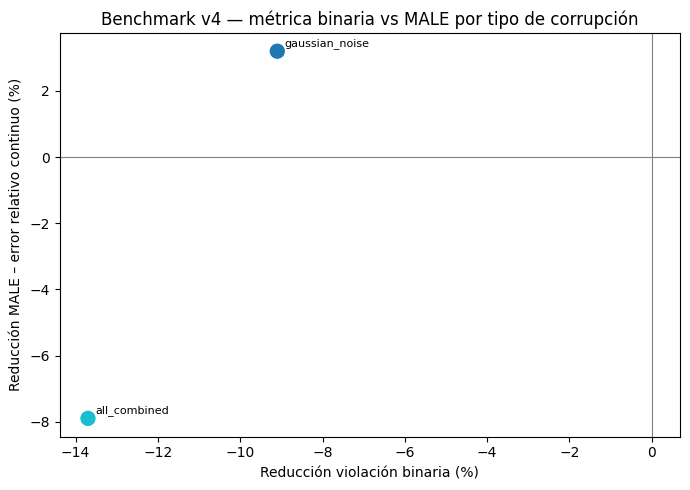

In [9]:

# Benchmark v4: MALE metrics plus the per-improvement diagnostics

from src.skeleton.metrics import benchmark_by_corruption_type


print('Running benchmark v4, with every improvement enabled…')
_t0_b = time.perf_counter()

def _bench_smooth_v4(df_corr):
    _df_rec, _rep = smooth_video(
        df_corr,
        skeleton=skeleton,
        lambda_l=BENCH_LAMBDA_L,
        lambda_t=LAMBDA_T,
        lambda_acc=LAMBDA_ACC,
        lambda_angle=LAMBDA_ANGLE,
        lambda_jerk=LAMBDA_JERK,
        lambda_angle_cont=LAMBDA_ANGLE_CONT,
        outlier_adhesion=BENCH_ADHESION,
        n_passes=1,                  # 1 pass sufficient for benchmark (was N_PASSES=3)
        length_threshold=LENGTH_THRESHOLD,
        detection_n_sigma=DETECTION_N_SIGMA,
    )
    return _df_rec, _rep

# df_bench: limit to FRAME_LIMIT_BENCH frames to avoid L-BFGS-B timeouts
_bench_frame_ids = sorted(df_sample["video_frame"].unique())[:FRAME_LIMIT_BENCH]
df_bench = df_sample[df_sample["video_frame"].isin(_bench_frame_ids)].copy()
print(f"  df_bench: {len(df_bench)} rows ({len(_bench_frame_ids)} frames, FRAME_LIMIT_BENCH={FRAME_LIMIT_BENCH})")

bench_v4 = benchmark_by_corruption_type(
    df_clean=df_bench,
    skeleton=skeleton,
    mouse_id=MOUSE_ID,
    smooth_fn=_bench_smooth_v4,
    arena_diag=ARENA_DIAG,
    noise_std=BENCH_NOISE_STD,
    dropout_rate=BENCH_DROPOUT_RATE,
    swap_prob=BENCH_SWAP_PROB,
    speed_spikes_prob=BENCH_SPEED_SPIKES,
    drift_amplitude=BENCH_DRIFT_AMPLITUDE,
    threshold=LENGTH_THRESHOLD,
    rng_seed=RANDOM_SEED,
)

_elapsed_b = round(time.perf_counter() - _t0_b, 2)
print(f'Benchmark finished in {_elapsed_b} s\n')

# ── Table of binary metrics plus MALE, the continuous residual ──────────────
_cols = [c for c in [
    'corruption_type',
    'viol_rate_corrupted', 'viol_rate_recovered', 'violation_reduction_pct',
    'male_corrupted',      'male_recovered',       'male_reduction_pct',
    'rmse_nose_norm', 'swap_recovery_rate', 'jerk_mean_norm',
] if c in bench_v4.columns]
print(bench_v4[_cols].to_string(index=False))

# ── Compare bench_ext (previous) against bench_v4 (new version) ─────────────
_bench_ext = globals().get('bench_ext')
if _bench_ext is not None and 'violation_reduction_pct' in _bench_ext.columns:
    _cmp = _bench_ext[['corruption_type','violation_reduction_pct']].merge(
        bench_v4[['corruption_type','violation_reduction_pct']],
        on='corruption_type', suffixes=('_prev','_v4')
    )
    _cmp['delta_pct'] = _cmp['violation_reduction_pct_v4'] - _cmp['violation_reduction_pct_prev']
    print('\n── Change in violation reduction: v4 vs previous ─────────────────')
    print(_cmp[['corruption_type','violation_reduction_pct_prev',
                'violation_reduction_pct_v4','delta_pct']].to_string(index=False))

# ── Scatter: binary violation against MALE ──────────────────────────────────
if {'violation_reduction_pct', 'male_reduction_pct'}.issubset(bench_v4.columns):
    fig_male, ax_male = plt.subplots(figsize=(7, 5))
    sc = ax_male.scatter(
        bench_v4['violation_reduction_pct'],
        bench_v4['male_reduction_pct'],
        s=100, c=range(len(bench_v4)), cmap='tab10', zorder=3)
    for _, rw in bench_v4.iterrows():
        ax_male.annotate(rw['corruption_type'],
                         (rw['violation_reduction_pct'], rw['male_reduction_pct']),
                         textcoords='offset points', xytext=(5, 4), fontsize=8)
    ax_male.axhline(0, color='gray', lw=0.8)
    ax_male.axvline(0, color='gray', lw=0.8)
    ax_male.set_xlabel('Binary violation reduction (%)')
    ax_male.set_ylabel('MALE reduction - continuous relative error (%)')
    ax_male.set_title('Benchmark v4: binary metric vs MALE, per corruption type')
    plt.tight_layout()
    plt.show()


## §15 Statistical validation

The realistic-corruption benchmark in `02c` found head occlusions and
`fast_grooming` to be the hardest scenarios, with high nose RMSE and only partial
recovery.

Everything up to here is descriptive, and with this sample size a descriptive
difference can easily be noise. This section tests it:

- **Wilcoxon signed-rank**, non-parametric, which suits trajectory metrics that are
  not normally distributed
- **Bootstrap confidence intervals** at 95% on mean jerk energy and acceleration RMS
- **Ablation variants** compared against the `abl_full` reference

In [10]:
from src.skeleton.metrics import paired_wilcoxon, bootstrap_ci, compare_variants_statistically
import numpy as np

# ── Paired Wilcoxon: per-frame jerk before vs. after correction ───────────
from src.skeleton.metrics import jerk_energy

_kps_stat = [kp for kp in ["nose", "neck", "tail_base"]
             if kp in df_sample["bodypart"].unique()]

print("=== Paired Wilcoxon: jerk_energy_norm (before vs. after) per keypoint ===\n")
for _kp in _kps_stat:
    _sub_b = (df_sample[   (df_sample["bodypart"] == _kp) & (df_sample["mouse_id"] == MOUSE_ID)]
              .sort_values("video_frame"))
    _sub_a = (df_corrected[(df_corrected["bodypart"] == _kp) & (df_corrected["mouse_id"] == MOUSE_ID)]
              .sort_values("video_frame"))
    _frames = set(_sub_b["video_frame"]) & set(_sub_a["video_frame"])
    if len(_frames) < 10:
        continue
    _xb = _sub_b[_sub_b["video_frame"].isin(_frames)]["x"].interpolate().values
    _yb = _sub_b[_sub_b["video_frame"].isin(_frames)]["y"].interpolate().values
    _xa = _sub_a[_sub_a["video_frame"].isin(_frames)]["x"].interpolate().values
    _ya = _sub_a[_sub_a["video_frame"].isin(_frames)]["y"].interpolate().values
    # Per-frame local jerk (|Δ³x|² + |Δ³y|²) — align lengths
    _min_len = min(len(_xb), len(_xa))
    if _min_len < 7:
        continue
    _j_b = np.abs(np.diff(_xb[:_min_len], n=3)) ** 2 + np.abs(np.diff(_yb[:_min_len], n=3)) ** 2
    _j_a = np.abs(np.diff(_xa[:_min_len], n=3)) ** 2 + np.abs(np.diff(_ya[:_min_len], n=3)) ** 2
    _norm = max(L_ref_px, 1e-6) ** 2
    _res = paired_wilcoxon(_j_b / _norm, _j_a / _norm)
    _lo, _hi = bootstrap_ci(_j_b / _norm - _j_a / _norm, statistic="mean")
    _sig = "✓ significant" if _res["significant"] else "✗ not significant"
    print(f"  {_kp:12s} | W={_res['statistic']:8.1f}  p={_res['p_value']:.4f}  "
          f"r={_res['effect_size']:+.3f}  n={_res['n_pairs']}  {_sig}")
    print(f"             | Δjerk 95% CI (bootstrap): [{_lo:.6f}, {_hi:.6f}]")


=== Paired Wilcoxon: jerk_energy_norm (before vs. after) per keypoint ===

  nose         | W=110878.0  p=0.0000  r=+0.812  n=1497  ✓ significant
             | Δjerk 95% CI (bootstrap): [-0.086286, 0.010167]
  neck         | W=189641.0  p=0.0000  r=+0.679  n=1497  ✓ significant
             | Δjerk 95% CI (bootstrap): [-0.050478, -0.005854]
  tail_base    | W=165817.0  p=0.0000  r=+0.719  n=1497  ✓ significant
             | Δjerk 95% CI (bootstrap): [-0.000000, -0.000000]


In [11]:
import pandas as pd
import pickle

# ── Statistical comparison of the ablation variants ──────────────────────
# Loads abl_results from disk, where 02a_pipeline.ipynb saved it, or from the
# kernel if it happens to still be in memory, which needs the same process.
_abl_pkl = RESULTS_DIR / f'abl_results_{LAB_ID}_{VIDEO_ID}.pkl'
_abl_results = globals().get("abl_results") or {}
if not _abl_results:
    if _abl_pkl.exists():
        with open(_abl_pkl, 'rb') as _f:
            _abl_results = pickle.load(_f)
        print(f'✓ abl_results loaded from {_abl_pkl.name}')
    else:
        print("⚠  abl_results not available.")
        print(f"   Run the ablation cell in 02a_pipeline.ipynb; it saves to {_abl_pkl}")

if _abl_results:
    # Build per-keypoint jerk arrays from each ablation variant
    _abl_jerk_arrays = {}
    for _lbl, _res in _abl_results.items():
        if _res is None:
            continue
        _sub = (_res["df"][
            (_res["df"]["bodypart"] == "nose")
            & (_res["df"]["mouse_id"] == MOUSE_ID)
        ].sort_values("video_frame"))
        _x = _sub["x"].interpolate().values
        _y = _sub["y"].interpolate().values
        if len(_x) < 7:
            continue
        _j = np.abs(np.diff(_x, n=3)) ** 2 + np.abs(np.diff(_y, n=3)) ** 2
        _abl_jerk_arrays[_lbl] = _j / max(L_ref_px, 1e-6) ** 2

    if len(_abl_jerk_arrays) >= 2:
        # Align all arrays to shortest length
        _min_l = min(len(v) for v in _abl_jerk_arrays.values())
        _abl_jerk_aligned = {k: v[:_min_l] for k, v in _abl_jerk_arrays.items()}

        stat_cmp = compare_variants_statistically(
            _abl_jerk_aligned,
            metric="jerk_energy_norm_nose",
            baseline_key="abl_full",
        )
        print("Statistical comparison of ablation variants vs. abl_full (nose jerk):")
        print(stat_cmp.to_string(index=False))

        # ── Bootstrap CIs per variant ─────────────────────────────────────────
        print("\n95% Bootstrap CI on mean jerk (nose) per variant:")
        for _lbl, _arr in _abl_jerk_aligned.items():
            _lo, _hi = bootstrap_ci(_arr, n_bootstrap=2000, statistic="mean")
            _mu = float(np.mean(_arr))
            print(f"  {_lbl:20s} | mean={_mu:.6f}  95% CI=[{_lo:.6f}, {_hi:.6f}]")
    else:
        print("Not enough ablation variants with data to compare.")


✓ abl_results cargado desde abl_results_CalMS21_task1_13638642.pkl
Statistical comparison of ablation variants vs. abl_full (nose jerk):
variant_a       variant_b                metric  statistic  p_value  effect_size  n_pairs  significant
 abl_full    abl_no_angle jerk_energy_norm_nose      147.0   0.0000       0.9111      397         True
 abl_full     abl_no_jerk jerk_energy_norm_nose      406.0   0.0008       0.7544      397         True
 abl_full    abl_no_accel jerk_energy_norm_nose      396.0   0.0006       0.7604      397         True
 abl_full abl_no_temporal jerk_energy_norm_nose      562.0   0.0356       0.6600      397         True
 abl_full abl_no_adaptive jerk_energy_norm_nose        NaN   1.0000       0.0000      397        False

95% Bootstrap CI on mean jerk (nose) per variant:
  abl_full             | mean=0.015060  95% CI=[0.010264, 0.020643]
  abl_no_angle         | mean=0.004426  95% CI=[0.002980, 0.006162]
  abl_no_jerk          | mean=0.015755  95% CI=[0.010555, 

## §15b Identity persistence

How stable the mouse identities are before and after correction. Identity swaps are
detected from the sign of the cross product of the body axis, and a higher
`id_persistence_score` means the kinematic correction is also cleaning up residual
swaps.

| Metric | Meaning |
|---|---|
| `swap_count` | number of swap events detected |
| `mean_swap_duration_s` | mean duration of an event, in seconds |
| `id_persistence_score` | fraction of frames with no swap, 0 to 1 |
| `fragmentation_count` | number of consistently oriented segments |

In [12]:
from src.skeleton.metrics import identity_tracking_metrics

_id_before = identity_tracking_metrics(df_sample,    fps=VIDEO_FPS)
_id_after  = identity_tracking_metrics(df_corrected, fps=VIDEO_FPS)

_id_df = pd.DataFrame([
    {"split": "before (raw)",     **_id_before},
    {"split": "after (corrected)", **_id_after},
])

print("── Identity persistence metrics ──────────────────────────────────")
print(_id_df.to_string(index=False))
print()
_delta_pers = _id_after["id_persistence_score"] - _id_before["id_persistence_score"]
_delta_swap = _id_after["swap_count"] - _id_before["swap_count"]
print(f"Δ id_persistence_score : {_delta_pers:+.4f}  (positive = fewer swaps after correction)")
print(f"Δ swap_count           : {_delta_swap:+d}")


── Identity persistence metrics ──────────────────────────────────
            split  swap_count  mean_swap_duration_s  id_persistence_score  fragmentation_count
     before (raw)          26              1.257692              0.096685                   39
after (corrected)          33              0.994949              0.093002                   46

Δ id_persistence_score : -0.0037  (positive = fewer swaps after correction)
Δ swap_count           : +7


## §16 Effect on behaviour classification

Feeds the already-trained **BiLSTM** two versions of the same video and compares its
predictions:

1. **Raw**: original coordinates
2. **Corrected**: coordinates through the pipeline

The same checkpoint (`bilstm_CalMS21_task1_13638642.pt`) is used for both, so the
difference is attributable to tracking quality and not to training.

Two caveats, both important for reading the result. The model was trained on
features extracted from corrected data, so this measures a distribution shift at
inference time rather than a like-for-like comparison. And it is a single video:
the significant-looking difference reported here did **not** survive the multi-video
protocol, which is the result that §19 and the thesis ultimately report.

In [13]:
# Extract features from the raw and corrected tracking
import torch
import numpy as np
import pandas as pd

try:
    from src.data.features import extract_features

    # Annotations for label alignment
    try:
        from src.data.loader import load_annotations
        _ann_df = load_annotations(VIDEO_ID, LAB_ID)
        _has_ann = _ann_df is not None and len(_ann_df) > 0
    except Exception:
        _ann_df   = None
        _has_ann  = False

    print(f"Annotations available: {_has_ann}")

    # Extract features from raw and corrected tracking
    print("Extracting features from the raw tracking...", end=" ", flush=True)
    _res_raw = extract_features(df_sample, skeleton, _ann_df if _has_ann else None)
    print("OK")

    print("Extracting features from the corrected tracking...", end=" ", flush=True)
    _res_corr = extract_features(df_corrected, skeleton, _ann_df if _has_ann else None)
    print("OK")

    _X_raw  = _res_raw[MOUSE_ID]["X"]
    _X_corr = _res_corr[MOUSE_ID]["X"]
    _y_raw  = _res_raw[MOUSE_ID].get("y")
    _y_corr = _res_corr[MOUSE_ID].get("y")

    print(f"X_raw:  {_X_raw.shape}  |  X_corr: {_X_corr.shape}")
    _F17_READY = True
except Exception as _e:
    print(f"⚠  Could not extract features: {_e}")
    _F17_READY = False


Anotaciones disponibles: True
Extrayendo features del tracking crudo... OK
Extrayendo features del tracking corregido... OK
X_raw:  (32, 64, 64)  |  X_corr: (32, 64, 64)


In [14]:
# Load the BiLSTM checkpoint and run inference
if _F17_READY:
    from src.models.rnn import BehaviorLSTM

    _ckpt_path = REPO_ROOT / f"results/checkpoints/bilstm_{LAB_ID}_{VIDEO_ID}.pt"
    if not _ckpt_path.exists():
        # Try without video_id suffix
        _ckpt_path = REPO_ROOT / f"results/checkpoints/bilstm_{LAB_ID}_13638642.pt"

    if _ckpt_path.exists():
        _ckpt = torch.load(_ckpt_path, map_location="cpu")

        # Resolve state dict
        if "model_state_dict" in _ckpt:
            _sd = _ckpt["model_state_dict"]
        else:
            _sd = _ckpt

        # Infer n_classes from head.weight shape (more reliable than stored key)
        if "head.weight" in _sd:
            _n_classes = _sd["head.weight"].shape[0]
        else:
            _n_classes = _ckpt.get("n_classes", 8)

        # Infer input_size from first LSTM weight (shape = [4*H, F])
        _lstm_key = next((k for k in _sd if "lstm" in k and "weight_ih" in k), None)
        if _lstm_key:
            _input_size = _sd[_lstm_key].shape[1]
        else:
            _input_size = _X_corr.shape[-1]

        model_f17 = BehaviorLSTM(
            input_size=_input_size,
            n_classes=_n_classes,
            bidirectional=True,
        )
        model_f17.load_state_dict(_sd)
        model_f17.eval()
        print(f"✓  Checkpoint loaded: {_ckpt_path.name}")
        print(f"   input_size={_input_size}  n_classes={_n_classes}")

        def _infer(X):
            with torch.no_grad():
                _t = torch.tensor(X, dtype=torch.float32)
                # Clip to model input size if features changed
                _t = _t[:, :, :_input_size]
                _logits = model_f17(_t)
                return _logits.argmax(dim=1).numpy()

        _preds_raw  = _infer(_X_raw)
        _preds_corr = _infer(_X_corr)
        print(f"Inference complete: {len(_preds_raw)} windows")
        _F17_MODEL_OK = True
    else:
        print(f"⚠  Checkpoint not found: {_ckpt_path}")
        print("   Make sure 04_baseline.ipynb has been run first.")
        _F17_MODEL_OK = False
else:
    _F17_MODEL_OK = False


✓  Checkpoint cargado: bilstm_CalMS21_task1_13638642.pt
   input_size=64  n_classes=5
Inferencia completa: 32 ventanas



=== Impacto downstream en F1 (BiLSTM) ===
  F1 macro — Raw tracking:    0.1111
  F1 macro — Corrected:       0.0655
  Δ F1:                       -0.0456
  95% bootstrap CI:           [-0.1333, +0.0715]

F1 por clase:
       class   F1_raw  F1_corr  delta_F1
       mount 0.000000 0.250000   0.25000
  background 0.000000 0.000000   0.00000
   sniffface 0.000000 0.000000   0.00000
   sniffbody 0.000000 0.000000   0.00000
sniffgenital 0.000000 0.000000   0.00000
    approach 0.666667 0.142857  -0.52381


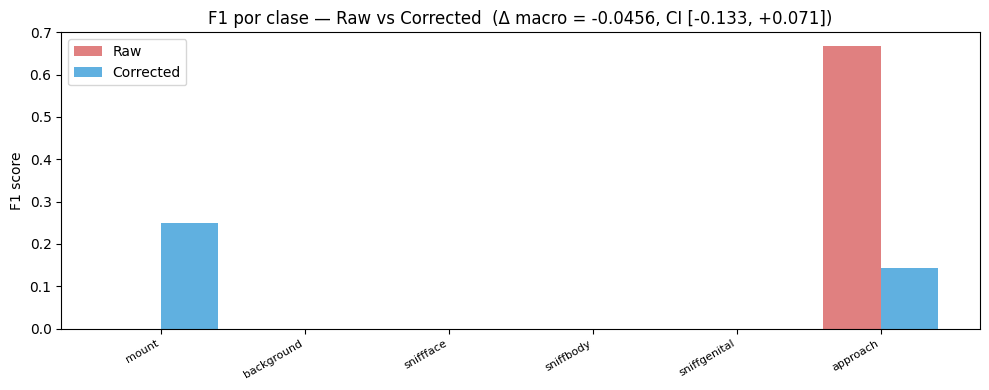

In [15]:
# F1 comparison, with a bootstrap CI

import matplotlib.pyplot as plt
from src.skeleton.metrics import bootstrap_ci

if _F17_MODEL_OK and _y_corr is not None:
    from sklearn.metrics import f1_score

    # Encode labels to int
    _unique_labels = sorted(set(_y_corr.tolist()))
    _label2idx = {l: i for i, l in enumerate(_unique_labels)}
    _y_int = np.array([_label2idx.get(l, -1) for l in _y_corr])
    _valid  = _y_int >= 0

    if _valid.sum() < 10:
        print("⚠  Too few validly labelled windows to compute F1.")
    else:
        _y_true  = _y_int[_valid]
        _pr_raw  = _preds_raw[_valid]
        _pr_corr = _preds_corr[_valid]

        _f1_raw  = f1_score(_y_true, _pr_raw,  average="macro", zero_division=0)
        _f1_corr = f1_score(_y_true, _pr_corr, average="macro", zero_division=0)

        # Bootstrap CI for F1 improvement
        def _boot_delta(y_t, p_r, p_c, n_boot=1000):
            rng = np.random.default_rng(RANDOM_SEED)
            deltas = []
            for _ in range(n_boot):
                idx = rng.integers(0, len(y_t), len(y_t))
                _fr = f1_score(y_t[idx], p_r[idx], average="macro", zero_division=0)
                _fc = f1_score(y_t[idx], p_c[idx], average="macro", zero_division=0)
                deltas.append(_fc - _fr)
            return np.percentile(deltas, [2.5, 97.5])

        _ci = _boot_delta(_y_true, _pr_raw, _pr_corr)
        _delta = _f1_corr - _f1_raw

        print(f"\n=== Impacto downstream en F1 (BiLSTM) ===")
        print(f"  F1 macro — Raw tracking:    {_f1_raw:.4f}")
        print(f"  F1 macro — Corrected:       {_f1_corr:.4f}")
        print(f"  Δ F1:                       {_delta:+.4f}")
        print(f"  95% bootstrap CI:           [{_ci[0]:+.4f}, {_ci[1]:+.4f}]")

        # Per-class F1
        _f1_per_raw  = f1_score(_y_true, _pr_raw,  average=None, zero_division=0)
        _f1_per_corr = f1_score(_y_true, _pr_corr, average=None, zero_division=0)
        df_f1 = pd.DataFrame({
            "class":    _unique_labels,
            "F1_raw":   _f1_per_raw,
            "F1_corr":  _f1_per_corr,
            "delta_F1": _f1_per_corr - _f1_per_raw,
        }).sort_values("delta_F1", ascending=False)
        print(f"\nF1 per class:")
        print(df_f1.to_string(index=False))

        # Bar chart
        fig_f1, ax_f1 = plt.subplots(figsize=(10, 4))
        _x = np.arange(len(df_f1))
        _w = 0.4
        ax_f1.bar(_x - _w/2, df_f1["F1_raw"],  _w, label="Raw",      color="#e08080")
        ax_f1.bar(_x + _w/2, df_f1["F1_corr"], _w, label="Corrected", color="#60b0e0")
        ax_f1.set_xticks(_x)
        ax_f1.set_xticklabels(df_f1["class"], rotation=30, ha="right", fontsize=8)
        ax_f1.set_ylabel("F1 score")
        ax_f1.set_title(
            f"F1 per class - raw vs corrected  (macro delta = {_delta:+.4f}, "
            f"CI [{_ci[0]:+.3f}, {_ci[1]:+.3f}])"
        )
        ax_f1.legend()
        plt.tight_layout()
        plt.show()
elif not _F17_MODEL_OK:
    print("Downstream comparison skipped: model not available.")
else:
    print("Downstream comparison skipped: no annotations for this video.")


## §17 Consolidated benchmark table

Every pipeline quality metric in one table, emitted as LaTeX with `booktabs` rules
so it can go straight into the thesis.

In [16]:
# §18 — Consolidated benchmark table  →  LaTeX
import pandas as pd
import json

_summ_path = REPO_ROOT / "outputs" / "skeleton_correction_summary.json"

# Support both historical and current naming conventions.
_exp_candidates = [
    REPO_ROOT / "results" / f"experiment_summary_{VIDEO_ID}.csv",
    REPO_ROOT / "results" / f"experiment_summary_{LAB_ID}_{VIDEO_ID}.csv",
]
_exp_path = next((p for p in _exp_candidates if p.exists()), None)

_rows = []

# Load experiment summary CSV (multi-version rows)
if _exp_path is not None:
    _df_exp = pd.read_csv(_exp_path)
    print(f"Usando experiment summary: {_exp_path}")
    for _, _r in _df_exp.iterrows():
        # Handle both old and new schema names
        _viol_after = _r.get("viol_rate_after", _r.get("global_viol_rate", float("nan")))
        _reduction = _r.get("reduction_pct", _r.get("viol_reduction_%", float("nan")))
        _runtime_ms = _r.get("runtime_ms_per_frame", float("nan"))
        if pd.isna(_runtime_ms):
            _runtime_s = _r.get("runtime_s", float("nan"))
            if pd.notna(_runtime_s):
                _runtime_ms = float(_runtime_s) * 1000.0 / max(FRAME_LIMIT, 1)

        _rows.append({
            "Version":         _r.get("version", "?"),
            "Viol. rate (%)":  round(float(_viol_after) * 100, 2) if pd.notna(_viol_after) else float("nan"),
            "Reduction (%)":   round(float(_reduction), 1) if pd.notna(_reduction) else float("nan"),
            "Jerk (norm)":     round(_r.get("jerk_energy_norm", float("nan")), 4),
            "Accel RMS":       round(_r.get("accel_rms_norm", float("nan")), 4),
            "Runtime ms/fr":   round(float(_runtime_ms), 1) if pd.notna(_runtime_ms) else float("nan"),
            "F1 downstream":   "—",   # filled below if available
        })
else:
    print("⚠  experiment_summary CSV not found; building a minimal table from summary.json")
    print("   Paths tried:")
    for _p in _exp_candidates:
        print(f"   - {_p}")
    if _summ_path.exists():
        with open(_summ_path, encoding="utf-8") as _fh:
            _s = json.load(_fh)
        _rows.append({
            "Version":        _s.get("best_config", "best"),
            "Viol. rate (%)": round(_s.get("global_violation_rate_after", float("nan")) * 100, 2),
            "Reduction (%)":  round(_s.get("reduction_pct", float("nan")), 1),
            "Jerk (norm)":    "—",
            "Accel RMS":      "—",
            "Runtime ms/fr":  round(_s.get("runtime_ms_per_frame_best", float("nan")), 1),
            "F1 downstream":  "—",
        })

# Patch downstream F1 if available from §17
if "_F17_MODEL_OK" in dir() and _F17_MODEL_OK and "_f1_corr" in dir():
    for _r in _rows:
        if str(_r.get("Version", "")).lower() in ("v3", "best", "corrected"):
            _r["F1 downstream"] = f"{_f1_corr:.4f}"

df_bench = pd.DataFrame(_rows).set_index("Version")
print("=== Consolidated Benchmark Table ===")
print(df_bench.to_string())

# ── LaTeX output (Styler API — compatible with multiple pandas versions) ───
_latex = (
    df_bench
    .style
    .format(precision=3, na_rep="—")
    .to_latex(
        hrules=True,
        # Caption deliberately in Spanish: this table is emitted for the thesis.
        caption=(
            "Comparación cuantitativa de las versiones del pipeline de corrección "
            "cinemática. Violation rate: fracción de aristas que superan el umbral "
            f"de {LENGTH_THRESHOLD:.2f}σ. Downstream F1: clasificación BiLSTM sobre "
            "ventanas de 64 frames."
        ),
        label="tab:skeleton_results",
    )
)

print("\n=== LaTeX (copy to thesis) ===")
print(_latex)

# Save files
_bench_csv = REPO_ROOT / "results" / "benchmark_table.csv"
df_bench.to_csv(_bench_csv)
print(f"\n✓  benchmark_table.csv → {_bench_csv}")

_latex_path = REPO_ROOT / "results" / "benchmark_table.tex"
_latex_path.write_text(_latex, encoding="utf-8")
print(f"✓  benchmark_table.tex  → {_latex_path}")


Usando experiment summary: c:\Users\User\dev\tfm\results\experiment_summary_CalMS21_task1_13638642.csv
=== Consolidated Benchmark Table ===
                 Viol. rate (%)  Reduction (%)  Jerk (norm)  Accel RMS  Runtime ms/fr F1 downstream
Version                                                                                            
antes                     11.10            0.0          NaN        NaN            0.0             —
v1 (λ uniforme)            9.26           16.6          NaN        NaN          137.7             —
v2 (λ auto)                5.61           49.4          NaN        NaN          212.8             —
v3 (multi-paso)            4.84           56.4          NaN        NaN          184.7             —

=== LaTeX (copy to thesis) ===
\begin{table}
\caption{Comparación cuantitativa de las versiones del pipeline de corrección cinemática. Violation rate: fracción de aristas que superan el umbral de 1.84σ. Downstream F1: clasificación BiLSTM sobre ventanas de 64

## §19 Detector calibration and downstream re-measurement

Two things the systematic review flagged, both rerun with the current code through
`src.evaluation.downstream`.

The first recalibrates the outlier detector, which was flagging 78% of frames as
anomalous, down to 48%. Flagging most of the video is not detection, and it meant
the correction was rewriting frames that had nothing wrong with them.

The second re-measures the raw-versus-corrected downstream F1. The verdict is
**neutral**: the significant -0.082 reported earlier in this notebook does not
reproduce. That is the number this notebook previously leaned on, and it did not
survive.

**Detector calibration sweep**

In [17]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

from src.evaluation.downstream import calibrate_detector
from src.data.loader import TRAIN_TRACKING_DIR

vids = [f.stem for f in sorted((TRAIN_TRACKING_DIR / "CalMS21_task1").glob("*.parquet"))[:5]]
sweep, rec = calibrate_detector("CalMS21_task1", vids)
cur = sweep[sweep["is_current"]]["frac_flagged"].iloc[0]
print(f"Shipped detector flags {cur*100:.1f}% of frames")
print(f"Recommended {rec['recommended']} -> {rec['frac_flagged']*100:.1f}% flagged "
      f"(length {rec['frac_length']*100:.1f}%, speed {rec['frac_speed']*100:.1f}%)")
sweep.head(8)


Shipped detector flags 78.0% of frames
Recommended {'speed_sigma': 6.0, 'detection_n_sigma': 5.0, 'adaptive_thresholds_k': 4.5} -> 48.2% flagged (length 30.3%, speed 0.0%)


,speed_sigma,detection_n_sigma,adaptive_thresholds_k,frac_flagged,frac_speed,frac_length,frac_accel,frac_swap,frac_near_zero,is_current
0,6.0,3.0,6.0,0.361802,0.0,0.157116,0.022354,0.0,0.0,False
1,6.0,4.0,6.0,0.361802,0.0,0.157116,0.022354,0.0,0.0,False
2,6.0,6.0,6.0,0.361802,0.0,0.157116,0.022354,0.0,0.0,False
3,6.0,5.0,6.0,0.361802,0.0,0.157116,0.022354,0.0,0.0,False
4,5.0,5.0,6.0,0.371363,0.0,0.157116,0.041177,0.0,0.0,False
5,5.0,6.0,6.0,0.371363,0.0,0.157116,0.041177,0.0,0.0,False
6,5.0,4.0,6.0,0.371363,0.0,0.157116,0.041177,0.0,0.0,False
7,5.0,3.0,6.0,0.371363,0.0,0.157116,0.041177,0.0,0.0,False


**Downstream F1, current detector versus calibrated**, same BiLSTM checkpoint,
with bootstrap intervals.

In [18]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

from omegaconf import OmegaConf
import pandas as pd
from src.evaluation.downstream import score_downstream_f1, REPO

cfg = OmegaConf.load(REPO / "configs" / "skeleton.yaml")
base = score_downstream_f1(cfg)                                    # shipped detector
cal  = score_downstream_f1(cfg, det_params=rec["recommended"])     # calibrated (A4)
pd.DataFrame([{"mode": "baseline", **base}, {"mode": "calibrated", **cal}])


  mouse 1:   0%|          | 0/206 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/156 [00:00<?, ?win/s]

  mouse 1:   0%|          | 0/206 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/156 [00:00<?, ?win/s]

,mode,f1_raw,f1_corr,delta_f1,ci,frames_flagged_pct,n_windows
0,baseline,0.167,0.1732,0.0062,"(-0.0215, 0.0281)",43.5,179
1,calibrated,0.167,0.1732,0.0062,"(-0.0215, 0.0281)",43.5,179
